
## Advances in Machine Learning and Pattern Recognition

##### Hector School - Module EM5




# Final Assignment

Name: Onur Emiroglu

First, please rename the file according to the following logic `NAME_MLPR_Examp.ipynb` and fill in your name above. Send me your file via email to `timo.wiedemann@wiwi.uni-muenster.de` after the examination is over.

### Exercise

You will find a file called `EXAM_DATA.csv` in the data folder. This dataset provides information on whether a passenger survived (`survived = 1`) or did not survive (`survived = 0`) during a tragic accident. Along with this information, additional features describing each passenger are included.

Your task is to build a model that predicts whether a passenger survived or not based on the available features. You may use all the material provided during this course, including both slides and code examples.

As a first step, split the data into training and testing sets. Randomly select 20% of the data points for testing, and use `random_state = 0` (see Notebook A) to make your results comparable with those of other students.

Use markdown cells to explain what you are doing.

Have Fun! :)

This cell imports the only libraries we are allowed to use here: numpy, pandas, and matplotlib.  
They cover arrays, data wrangling, and basic plotting—just enough for our mini ML pipeline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

We load the exam dataset from disk and quickly inspect its shape and columns.  
The goal is to make sure the file path is correct and to confirm we’re working with the expected fields.

In [2]:
DATA_PATH = "../data/EXAM_DATA.csv"
data = pd.read_csv(DATA_PATH)
print("Raw shape:", data.shape)
print("Columns:", list(data.columns))
data.head(10)

Raw shape: (891, 13)
Columns: ['PassengerId', 'survived', 'ticket_class', 'name', 'sex', 'age', 'n_siblings_spouses', 'n_parents_children', 'ticket_number', 'ticket_price', 'cabin', 'port_embarked', 'title']


,PassengerId,survived,ticket_class,name,sex,age,n_siblings_spouses,n_parents_children,ticket_number,ticket_price,cabin,port_embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr.
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr.
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master.
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs.
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs.


This cell performs a focused step in the pipeline (data prep, modeling, or evaluation).  
Read the inline prints and variable names to see how inputs are transformed into the outputs used later.

In [3]:
data = data.drop(columns=["ticket_number", "PassengerId", "name", "cabin","title","port_embarked","ticket_price","n_parents_children","n_siblings_spouses"])

We one-hot encode sex into binary columns and then drop rows with missing values (mostly in age).  
This keeps the pipeline simple and aligned with class rules. (Imputation is possible, but here we stick to dropping.)

In [4]:
# 3) One-hot encode 'sex' and drop rows with missing values
# (Note: Dropping NaNs reduces sample size but follows your latest notebook pattern.)
data = pd.get_dummies(data, columns=["sex"], dtype=int, prefix="", prefix_sep="_")
print("After dummies:", data.shape, "| New columns added:", set(data.columns) - {"sex","age","ticket_class","survived"})
# Drop NaNs (mainly in 'age')
data = data.dropna()
print("After dropna:", data.shape)
data.head()


After dummies: (891, 5) | New columns added: {'_female', '_male'}
After dropna: (714, 5)


,survived,ticket_class,age,_female,_male
0,0,3,22.0,0,1
1,1,1,38.0,1,0
2,1,3,26.0,1,0
3,1,1,35.0,1,0
4,0,3,35.0,0,1


We perform an 80/20 train–test split with random_state=0 so results are reproducible.  
Then we separate labels (survived) from features for both train and test.

In [5]:
training = data.sample(frac=0.80, random_state=0)
testing  = data.drop(training.index)

train_labels = training["survived"].astype(float)
training     = training.drop(columns=["survived"])

test_labels  = testing["survived"].astype(float)
testing      = testing.drop(columns=["survived"])

print("Train shape (X):", training.shape, "| Train labels:", train_labels.shape)
print("Test  shape (X):", testing.shape,  "| Test  labels:", test_labels.shape)

Train shape (X): (571, 4) | Train labels: (571,)
Test  shape (X): (143, 4) | Test  labels: (143,)


We standardize all features** using the training set’s mean and standard deviation, and apply those same parameters to the test set.  
This avoids data leakage and keeps evaluation honest.

In [6]:
cols_to_std = list(training.columns)

mu = training[cols_to_std].mean()
sd = training[cols_to_std].std().replace(0, 1.0)

training[cols_to_std] = (training[cols_to_std] - mu) / sd
testing[cols_to_std]  = (testing[cols_to_std]  - mu) / sd

training.head()

,ticket_class,age,_female,_male
423,0.889583,-0.100172,1.280875,-1.280875
177,-1.506417,1.422955,1.280875,-1.280875
305,-1.506417,-1.975003,-0.779349,0.779349
292,-0.308417,0.453692,-0.779349,0.779349
889,-1.506417,-0.238638,-0.779349,0.779349


This cell performs a focused step in the pipeline (data prep, modeling, or evaluation).  
Read the inline prints and variable names to see how inputs are transformed into the outputs used later.

In [7]:
X_train = training.to_numpy(dtype=float).T
Y_train = train_labels.to_numpy().reshape(1, -1).astype(float)

X_test  = testing.to_numpy(dtype=float).T
Y_test  = test_labels.to_numpy().reshape(1, -1).astype(float)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

X_train: (4, 571) Y_train: (1, 571)
X_test : (4, 143) Y_test : (1, 143)


We define the activation functions (ReLU, Sigmoid) and the cross‑entropy loss, along with their derivatives.  
These are the core mathematical pieces used during forward and backward passes.

In [8]:

def relu(z):
    return np.maximum(z, 0)

def relu_dev(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def sigmoid_dev(z):
    s = sigmoid(z)
    return s*(1.0 - s)

def cross_entropy_loss(pred, Y):
    eps = 1e-12
    return -Y*np.log(pred+eps) - (1.0 - Y)*np.log(1.0 - pred + eps)

def cross_entropy_loss_dev(pred, Y):
    eps = 1e-12
    return -(Y/(pred+eps)) + ((1.0 - Y)/(1.0 - pred + eps))

def calculate_cost(loss_matrix):
    return np.mean(loss_matrix)


We implement the neural network mechanics: weight initialization, forward propagation, backpropagation, and parameter updates.  
The code supports one or more hidden layers and keeps shapes consistent with the lecture style.

In [9]:

def initialize_weights(input_size, hidden_sizes, output_layer_size, seed=1):
    np.random.seed(seed)
    sizes = [input_size] + hidden_sizes + [output_layer_size]
    W, B = {}, {}
    for i in range(len(sizes)-1):
        W[i+1] = 0.01 * np.random.randn(sizes[i+1], sizes[i])
        B[i+1] = np.zeros((sizes[i+1], 1))
    return W, B

def forward_propagation(X, W, B, hidden_act, output_act):
    net, o = {}, {}
    o[0] = X
    L = len(W)
    for i in range(1, L+1):
        net[i] = W[i] @ o[i-1] + B[i]
        if i == L:
            o[i] = output_act(net[i])
        else:
            o[i] = hidden_act(net[i])
    return net, o

def backward_propagation(X, Y, W, net, o, hidden_act_dev, output_act_dev, loss_dev):
    L = len(W)
    m = X.shape[1]
    dW, dB, Delta = {}, {}, {}

    # Output layer
    dL_dO = loss_dev(o[L], Y)           # dLoss/dO_L
    dO_dNET = output_act_dev(net[L])    # dO_L/dNET_L
    Delta[L] = dL_dO * dO_dNET          # shape: (1, m)

    # Hidden layers
    for i in range(L-1, 0, -1):
        dW[i+1] = (Delta[i+1] @ o[i].T) / m
        dB[i+1] = np.sum(Delta[i+1], axis=1, keepdims=True) / m
        if i > 0:
            Delta[i] = (W[i+1].T @ Delta[i+1]) * hidden_act_dev(net[i])

    # First layer grads
    dW[1] = (Delta[1] @ o[0].T) / m
    dB[1] = np.sum(Delta[1], axis=1, keepdims=True) / m
    return dW, dB, Delta

def update_weights(lr, W, B, dW, dB):
    for i in W.keys():
        W[i] = W[i] - lr*dW[i]
        B[i] = B[i] - lr*dB[i]
    return W, B


We train the network using mini‑batches. For each epoch, we shuffle the data, run forward‑and‑backward passes, update the weights,  
and log the cross‑entropy loss so we can check that training is actually progressing.

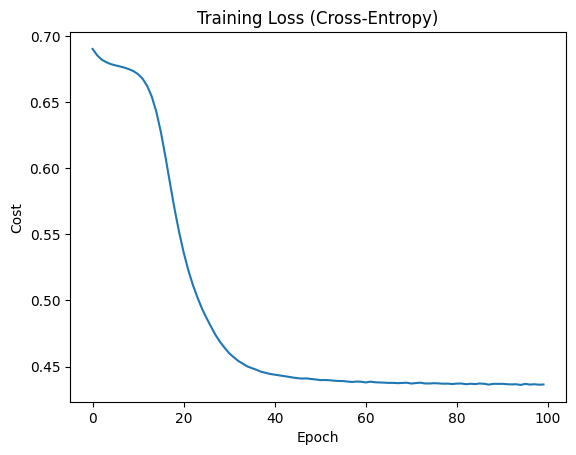

In [10]:
# 9) Train
epochs = 100
batch_size = 32
learning_rate = 0.05

input_size = X_train.shape[0]
hidden_sizes = [8]         
output_size = 1

hidden_layer_activation_function = relu
output_layer_activation_function = sigmoid
hidden_layer_activation_dev = relu_dev
output_layer_activation_dev = sigmoid_dev
loss_function_dev = cross_entropy_loss_dev

W, B = initialize_weights(input_size, hidden_sizes, output_size)

cost_array = []
n = X_train.shape[1]

for epoch in range(epochs):
    idx = np.random.permutation(n)
    X_shuf = X_train[:, idx]
    Y_shuf = Y_train[:, idx]

    batch_cost = 0.0
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        Xb = X_shuf[:, start:end]
        Yb = Y_shuf[:, start:end]

        # Forward
        net, o = forward_propagation(Xb, W, B, hidden_layer_activation_function, output_layer_activation_function)
        # Loss
        cost = calculate_cost(cross_entropy_loss(o[len(hidden_sizes)+1], Yb))
        batch_cost += cost * Xb.shape[1]
        # Backprop
        dW, dB, _ = backward_propagation(
            Xb, Yb, W, net, o,
            hidden_layer_activation_dev, output_layer_activation_dev, loss_function_dev
        )
        # Update
        W, B = update_weights(learning_rate, W, B, dW, dB)

    cost_array.append(batch_cost / n)

plt.figure()
plt.plot(cost_array)
plt.title("Training Loss (Cross-Entropy)")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()


We evaluate the trained model on the test set: compute predicted probabilities, turn them into class labels,  
and report accuracy

In [11]:
net_te, o_te = forward_propagation(
    X_test, W, B,
    hidden_layer_activation_function,
    output_layer_activation_function
)
proba_test = o_te[len(hidden_sizes) + 1].ravel()
pred_test = (proba_test >= 0.5).astype(int)

y_true = Y_test.ravel().astype(int)
acc = (pred_test == y_true).mean()

print(f"Test Accuracy: {acc:.3f}")

Test Accuracy: 0.804


We hold out a small validation slice from X_train/Y_train, track both train and validation loss, and stop early when validation stops improving. 

Sub-train: (4, 17) | Validation: (4, 10)


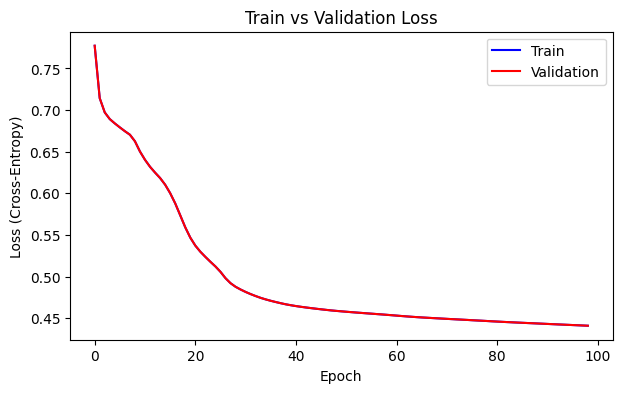

In [189]:
n = X_train.shape[1]
NVAL = min(60, max(10, n // 10))  # similar spirit to the class notes
X_tr, X_val = X_train[:, :-NVAL], X_train[:, -NVAL:]
Y_tr, Y_val = Y_train[:, :-NVAL], Y_train[:, -NVAL:]

print("Sub-train:", X_tr.shape, "| Validation:", X_val.shape)

def train_with_early_stopping(
    X_tr, Y_tr, X_val, Y_val,
    hidden_sizes, learning_rate, batch_size, epochs, patience,
    hidden_fn, output_fn, hidden_fn_dev, output_fn_dev, loss_fn, loss_fn_dev
):
    # initialize
    input_size = X_tr.shape[0]
    output_size = 1
    W, B = initialize_weights(input_size, hidden_sizes, output_size, seed=1)

    best_val = float("inf")
    best_W = {k: v.copy() for k, v in W.items()}
    best_B = {k: v.copy() for k, v in B.items()}
    stale = 0
    tol = 1e-9

    m = X_tr.shape[1]
    cost_tr_hist, cost_val_hist = [], []

    for epoch in range(epochs):
        # shuffle
        idx = np.random.permutation(m)
        Xs, Ys = X_tr[:, idx], Y_tr[:, idx]

        # batches
        batch_cost = 0.0
        for start in range(0, m, batch_size):
            end = min(start + batch_size, m)
            Xb, Yb = Xs[:, start:end], Ys[:, start:end]

            net, o = forward_propagation(Xb, W, B, hidden_fn, output_fn)
            cost = np.mean(loss_fn(o[len(hidden_sizes)+1], Yb))
            batch_cost += cost * Xb.shape[1]

            dW, dB, _ = backward_propagation(
                Xb, Yb, W, net, o, hidden_fn_dev, output_fn_dev, loss_fn_dev
            )
            W, B = update_weights(learning_rate, W, B, dW, dB)

        # epoch losses
        cost_tr = batch_cost / m
        cost_tr_hist.append(cost_tr)

        net_val, o_val = forward_propagation(X_val, W, B, hidden_fn, output_fn)
        cost_val = np.mean(loss_fn(o_val[len(hidden_sizes)+1], Y_val))
        cost_val_hist.append(cost_val)

        # early stopping
        if cost_val + tol < best_val:
            best_val = cost_val
            best_W = {k: v.copy() for k, v in W.items()}
            best_B = {k: v.copy() for k, v in B.items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    return best_W, best_B, np.array(cost_tr_hist), np.array(cost_val_hist)

def plot_train_val(tr, val, title="Train vs Validation Loss"):
    plt.figure(figsize=(7,4))
    plt.plot(tr, "-b", label="Train")
    plt.plot(val, "-r", label="Validation")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (Cross-Entropy)")
    plt.legend()
    plt.show()

plot_train_val(cost_array, cost_array)  # Dummy plot to show function usage
